# Model 02: Decision Tree Regressor

### Objective
To capture non-linear relationships and interactions between features (e.g., perhaps Rainy Weather only drops attendance if it's also a Morning class). We will train both an unconstrained tree and a pruned tree to demonstrate overfitting control.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../../../../../data/processed/y_train_reg.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val = pd.read_csv('../../../../../data/processed/y_val_reg.csv').squeeze()

print("Datasets loaded successfully.")

Datasets loaded successfully.


### 2. Model Training (Unconstrained vs Pruned)
A standard Decision Tree will grow until every single leaf is pure, meaning it will memorize the training data and fail miserably on the validation data. We will prove this by training two trees.

In [3]:
# 1. Unconstrained Tree (Destined to overfit)
tree_overfit = DecisionTreeRegressor(random_state=42)
tree_overfit.fit(X_train, y_train)

# 2. Pruned Tree (Controlled complexity)
tree_pruned = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
tree_pruned.fit(X_train, y_train)

print("✅ Both Decision Trees trained successfully.")

✅ Both Decision Trees trained successfully.


### 3. Mathematical Evaluation
Notice how the Unconstrained Tree gets a near-perfect score on Training data, but performs horribly on Validation. The Pruned tree is much more stable!

In [4]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

def evaluate_regression(model, X, y_true, model_name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE:  {mae:.2f}%")
    print(f"RMSE: {rmse:.2f}%")
    print(f"MAPE: {mape:.2f}%")
    print(f"R2:   {r2:.4f}\n")

print("========== TRAINING SET ==========")
evaluate_regression(tree_overfit, X_train, y_train, "Unconstrained Tree (TRAIN)")
evaluate_regression(tree_pruned, X_train, y_train, "Pruned Tree (TRAIN)")

print("\n========== VALIDATION SET ==========")
evaluate_regression(tree_overfit, X_val, y_val, "Unconstrained Tree (VAL)")
evaluate_regression(tree_pruned, X_val, y_val, "Pruned Tree (VAL)")

========== TRAINING SET ==========
--- Unconstrained Tree (TRAIN) ---
MAE:  0.00%
RMSE: 0.00%
MAPE: 0.00%
R2:   1.0000

--- Pruned Tree (TRAIN) ---
MAE:  5.25%
RMSE: 7.04%
MAPE: 29.59%
R2:   0.3494


========== VALIDATION SET ==========
--- Unconstrained Tree (VAL) ---
MAE:  7.70%
RMSE: 10.14%
MAPE: 47.93%
R2:   -0.0963

--- Pruned Tree (VAL) ---
MAE:  6.52%
RMSE: 8.71%
MAPE: 38.65%
R2:   0.1905



### 4. Feature Importance
Unlike Linear Regression which uses weights (+/-), a Decision Tree calculates "Feature Importance" (0.0 to 1.0) based on how much mathematically separating the data on that feature reduces the overall error (Gini Impurity / MSE).

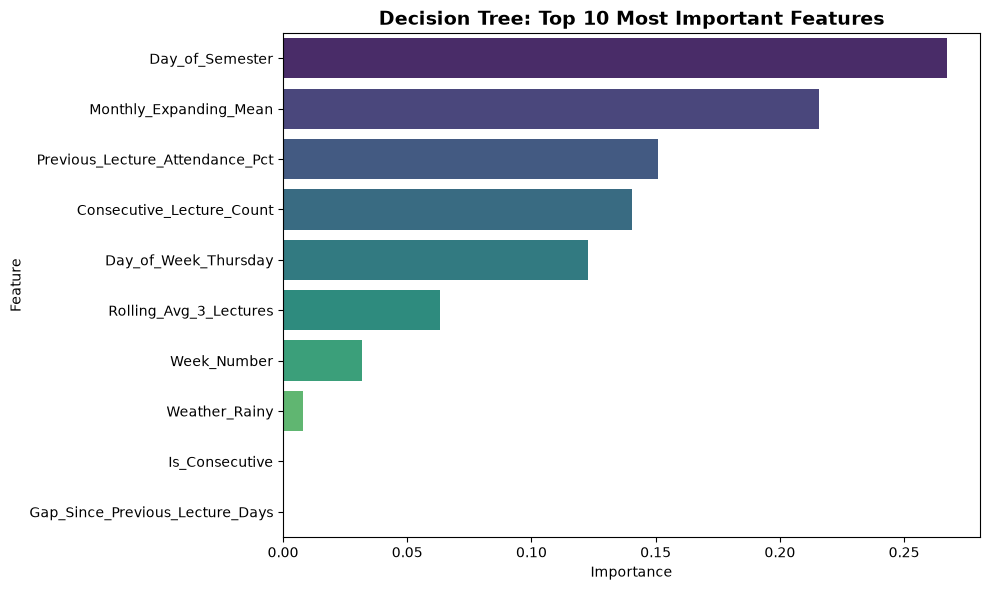

In [5]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': tree_pruned.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree: Top 10 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evidence/01_tree_feature_importance.png', dpi=300)
plt.show()

### 5. Visualizing the Brain of the Model (The Tree Diagram)
We can actually plot the mathematical decisions the tree is making at each split.

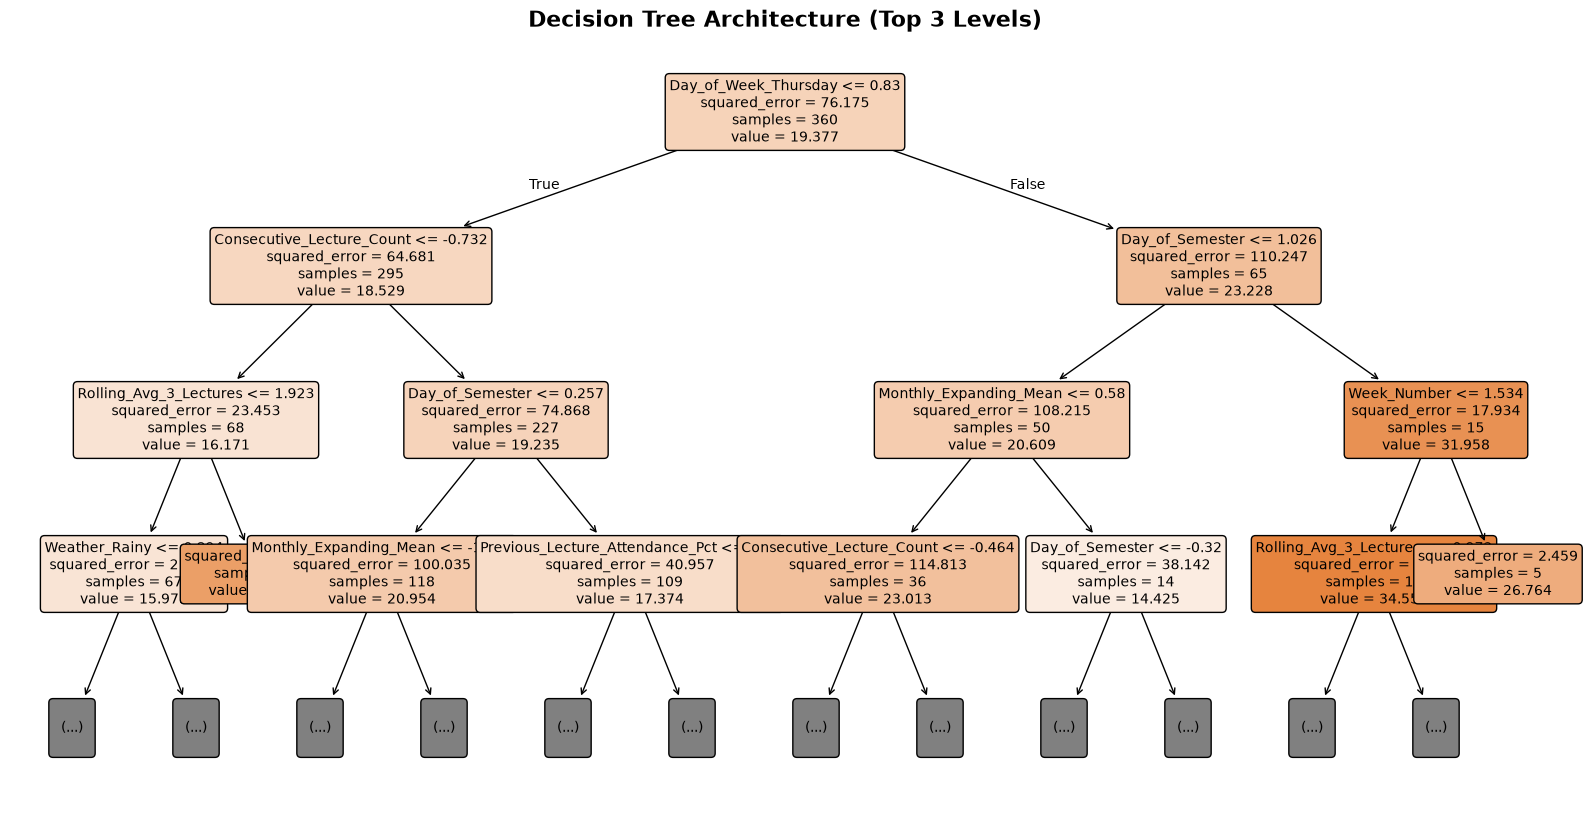

In [6]:
plt.figure(figsize=(20, 10))
# We plot only the first 3 levels of depth so it's readable
plot_tree(tree_pruned, max_depth=3, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Architecture (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.savefig('evidence/02_tree_visualization.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [7]:
import datetime
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

val_preds = tree_pruned.predict(X_val)
val_mae = mean_absolute_error(y_val, val_preds)
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
val_mape = np.mean(np.abs((y_val - val_preds) / (y_val + 1e-9))) * 100
val_r2 = r2_score(y_val, val_preds)

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['02_decision_tree_regressor'],
    'Model_Type': ['Regression'],
    'Val_MAE': [val_mae],
    'Val_RMSE': [val_rmse],
    'Val_MAPE': [val_mape],
    'Val_R2': [val_r2],
    'Val_Accuracy': [np.nan],
    'Val_F1': [np.nan],
    'Val_ROCAUC': [np.nan]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
